In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.signal import convolve2d



In [2]:
#utility functions
def vec(x_img):
    """
    Input:
        x_img : array of shape (H, W)
    Output:
        x_vec : array of shape (H*W,)
    """
    return x_img.reshape(-1)


def img(x_vec, shape):
    """
    Input:
        x_vec : array of shape (H*W,)
        shape : (H, W)
    Output:
        x_img : array of shape (H, W)
    """
    return x_vec.reshape(shape)


Image shape: (128, 128)


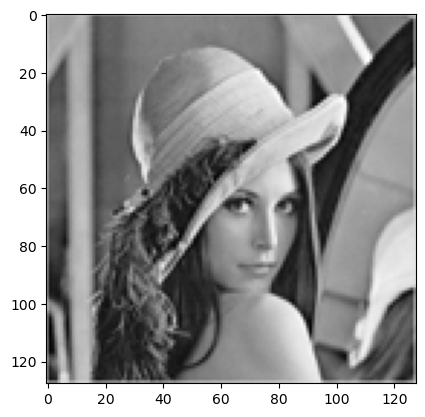

In [3]:
def load_grayscale_image(path, N=128):
    """
    Load image, convert to grayscale, resize/crop to NxN,
    and normalize pixel values to [0, 1].
    """
    img = Image.open(path).convert("L")  # L = grayscale

    # Resize if needed (keeps things simple)
    if img.size != (N, N):
        img = img.resize((N, N), resample=Image.BICUBIC)

    x = np.asarray(img, dtype=np.float64)

    # Normalize to [0, 1]
    x = (x - x.min()) / (x.max() - x.min()) #the image i use is already normalized 

    return x

x_img = load_grayscale_image('woman.png')
plt.imshow(x_img, cmap="gray")
print('Image shape:', x_img.shape)

Shape of blurred image: (128, 128)


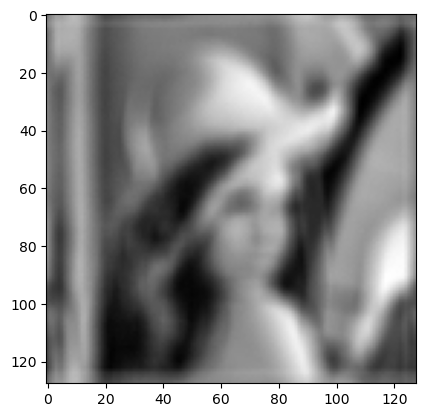

In [4]:
#add blur + gaussian noise to image

def uniform_blur_kernel(k=9):
    """
    Uniform blur kernel of dimension k
    """
    h = np.ones((k, k))
    h /= h.sum()
    return h

def A(x_img, h):
    return convolve2d(x_img, h, mode="same", boundary="wrap")

def AT(x_img, h):
    h_flip = h[::-1, ::-1]
    return convolve2d(x_img, h_flip, mode="same", boundary="wrap")

def add_blur(x_img,h, sigma=0.05):
    return A(x_img,h) + sigma * np.random.randn(*x_img.shape)

h = uniform_blur_kernel()
y_img = add_blur(x_img,h,sigma=0.0024)
plt.imshow(y_img, cmap='gray')
print('Shape of blurred image:', y_img.shape)

In [5]:
#define the Total Variation pipeline
def grad_data(x_img, y_img, h, sigma):
    """
    Input:
        x_img : (256,256)
        y_img : (256,256)
        h     : blur kernel
        sigma : noise std
    Output:
        grad  : (256,256)
    """
    return AT(A(x_img, h) - y_img, h) / sigma**2

def grad_forward(x):
    """
    Forward finite differences (Neumann boundary: last row/col derivative = 0).
    Returns gx, gy with same shape as x.
    """
    gx = np.zeros_like(x)
    gy = np.zeros_like(x)
    
    #difference between a pixel and its top and bottom neighbors on one axis 
    gx[:-1, :] = x[1:, :] - x[:-1, :]
    #other axis
    gy[:, :-1] = x[:, 1:] - x[:, :-1]

    return gx, gy

def div_backward(px, py):
    """
    Divergence operator corresponding to the forward gradient above.
    """
    div = np.zeros_like(px)

    # x-component
    div[:-1, :] -= px[:-1, :]
    div[1:, :]  += px[:-1, :]

    # y-component
    div[:, :-1] -= py[:, :-1]
    div[:, 1:]  += py[:, :-1]

    return div

def tv_norm(x):
    gx, gy = grad_forward(x)
    return np.sum(np.abs(gx) + np.abs(gy))

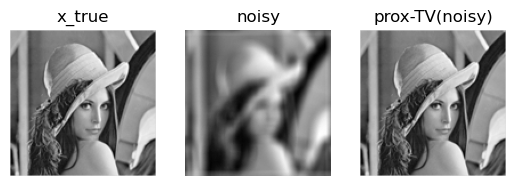

In [6]:
#dealing with non differentiability
def prox_tv_chambolle(x, lam, n_iter=50):
    """
    Compute prox_{lam * TV}(x) using Chambolle's algorithm.
    lam > 0 controls denoising strength.
    """
    px = np.zeros_like(x)
    py = np.zeros_like(x)
    tau = 0.25  # stable step

    for _ in range(n_iter):
        div_p = div_backward(px, py)
        gx, gy = grad_forward(div_p - x / lam)

        px_new = px + tau * gx
        py_new = py + tau * gy

        # projection step: enforce |p| <= 1 pointwise
        norm = np.maximum(1.0, np.sqrt(px_new**2 + py_new**2))
        px = px_new / norm
        py = py_new / norm

    # primal solution
    return x - lam * div_backward(px, py)


def grad_tv_moreau(x, lam, theta=10.74, n_iter=50):
        """
        Gradient of the Moreau-Yosida envelope of g(x)=theta*TV(x).
        """
        prox = prox_tv_chambolle(x, lam*theta, n_iter=n_iter)
        return (x - prox) / lam



x_denoised = prox_tv_chambolle(x_img, lam=2.83e-5, n_iter=100)

plt.subplot(1,3,1); plt.imshow(x_img, cmap="gray"); plt.title("x_true"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(y_img, cmap="gray"); plt.title("noisy"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(x_denoised, cmap="gray"); plt.title("prox-TV(noisy)"); plt.axis("off")
plt.show()

In [7]:
from langevin_samplers import (
    run_hmc,
    run_k_langevin,
    run_od_langevin
)

sigma = 0.0024
lam = 2.83e-5
theta=10.74
m=1
x_img = load_grayscale_image('woman.png', N=128)
x_img_red = np.asarray(x_img, dtype=np.float32)
y_img = add_blur(x_img,h, sigma=sigma)
x0 = vec(y_img.copy())
v0 = np.random.randn(*x0.shape)



def gradU_img(x_img, y_img, h, sigma, lam, theta, m):
    """
    Input:
        x_img : (256,256)
    Output:
        grad  : (256,256)
    """
    return (
        grad_data(x_img, y_img, h, sigma)
        + grad_tv_moreau(x_img, lam, theta) 
        + m*x_img
    ) 

def make_gradU(y_img, h, sigma, lam, theta, m, shape=(128,128)):
    def gradU_vector(x_vec):
        x_img = img(x_vec, shape)
        g_img = gradU_img(
            x_img,
            y_img=y_img,
            h=h,
            sigma=sigma,
            lam=lam,
            theta=theta, m=m
        )
        return vec(g_img)
    return gradU_vector

gradU = make_gradU(
    y_img=y_img,
    h=h,
    sigma=sigma,
    lam=lam,
    theta=theta, 
    m=m
)


X, V = run_od_langevin(
    x0,
    v0,
    gradU,
    N=1000,
    delta=1e-4,
    K=1
)


In [8]:
plt.imshow(img(X.mean, (128,128)))

AttributeError: 'builtin_function_or_method' object has no attribute 'reshape'

In [ ]:
from langevin_samplers import (
    run_hmc,
    run_k_langevin,
    run_od_langevin,
    run_od_langevin_streaming
)

sigma = 0.0024
lam = 2.83e-5
theta=10.74
m=1
x_img = load_grayscale_image('woman.png', N=128)
x_img_red = np.asarray(x_img, dtype=np.float32)
y_img = add_blur(x_img,h, sigma=sigma)
x0 = vec(y_img.copy())
v0 = np.random.randn(*x0.shape)



def gradU_img(x_img, y_img, h, sigma, lam, theta, m):
    """
    Input:
        x_img : (256,256)
    Output:
        grad  : (256,256)
    """
    return (
        grad_data(x_img, y_img, h, sigma)
        + grad_tv_moreau(x_img, lam, theta) 
        + m*x_img
    ) 

def make_gradU(y_img, h, sigma, lam, theta, m, shape=(128,128)):
    def gradU_vector(x_vec):
        x_img = img(x_vec, shape)
        g_img = gradU_img(
            x_img,
            y_img=y_img,
            h=h,
            sigma=sigma,
            lam=lam,
            theta=theta, m=m
        )
        return vec(g_img)
    return gradU_vector

gradU = make_gradU(
    y_img=y_img,
    h=h,
    sigma=sigma,
    lam=lam,
    theta=theta, 
    m=m
)


mean_x = run_od_langevin_streaming(
    x0,
    v0,
    gradU,
    N=1000,
    delta=1e-5,
    K=1,
    eta=0.0,
    burn=20000,
    thin=10
)



(-0.5, 127.5, 127.5, -0.5)

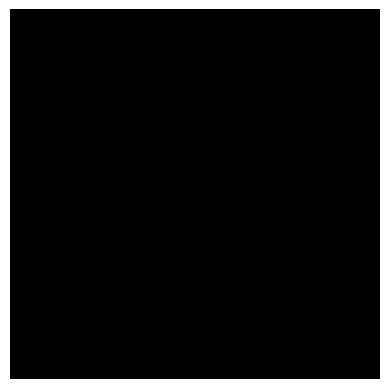

In [10]:
plt.imshow(mean_x.reshape(128,128), cmap="gray")
plt.axis("off")


(-0.5, 127.5, 127.5, -0.5)

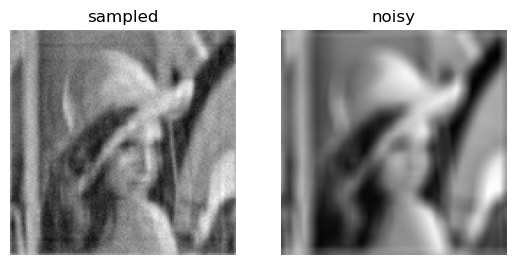

In [ ]:

plt.subplot(1,2,1); plt.imshow(mean_x.reshape(128,128), cmap="gray"); plt.title("sampled"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(y_img, cmap="gray"); plt.title("noisy"); plt.axis("off")



In [ ]:
x_last_img = img(X[-1], (256, 256))
plt.imshow(x_last_img, cmap="gray")


ValueError: cannot reshape array of size 16384 into shape (256,256)

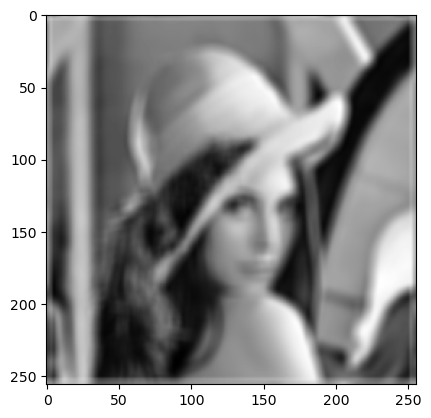

In [ ]:
burn = X.shape[0] // 2
X_post = X[burn:]

x_post_mean_img = img(X_post.mean(axis=0), (256, 256))

plt.imshow(x_post_mean_img, cmap="gray")